# Decomposition Results: TFIM vs Naive vs Trotter

## Load data

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find Results/ whether this notebook runs from Results/ or the repo root
results_dir = os.getcwd()
if os.path.basename(results_dir) != "Results" and os.path.isdir("Results"):
    results_dir = os.path.abspath("Results")

def load(name):
    path = os.path.join(results_dir, name)
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f"(missing) {name}")
        return None
    df = pd.read_csv(path, skipinitialspace=True, na_values=["N/A"])
    df.columns = df.columns.str.strip()
    # append-mode files can accumulate duplicates across re-runs; keep the latest
    keys = [k for k in ("n_qubits", "trotter_steps") if k in df.columns]
    if keys:
        df = df.drop_duplicates(keys, keep="last").sort_values(keys).reset_index(drop=True)
    return df

# All three pipelines now write a single results file with a common schema:
#   n_qubits, total_time, decomposition_time, error, total_gates, cnot, single_qubit, elementary_total
# (Trotter additionally carries trotter_steps and verification_time.)
tfim  = load("TFIM_decomposition_results.txt")
trot  = load("TFIM_trotter_results.txt")
naive = load("Naive_decomposition_results.txt")

# Representative Trotter slice for the vs-n comparisons: r = n
trot_rep = None
if trot is not None:
    trot_rep = (trot[trot["trotter_steps"] == trot["n_qubits"]]
                .drop_duplicates("n_qubits", keep="last").sort_values("n_qubits"))

for label, df in [("TFIM", tfim), ("Trotter", trot), ("Naive", naive)]:
    print(f"{label:8s}: {0 if df is None else len(df)} rows")

# --- plotting hygiene for log-scale error plots ---
# n=1 is degenerate: the TFIM Hamiltonian has no coupling term (single-site field
# only), so first-order Trotter is exact and the error is ~0, which collapses or
# gaps on a log axis. Likewise, reconstruction errors below ERR_FLOOR are
# floating-point noise (the exact methods sit at machine precision). We drop both.
N_MIN = 2
ERR_FLOOR = 1e-16

def clean_err(df):
    """Drop NaN errors, n < N_MIN, and sub-ERR_FLOOR noise for log-scale plots."""
    if df is None or "error" not in df:
        return None
    d = df.dropna(subset=["error"])
    return d[(d["n_qubits"] >= N_MIN) & (d["error"] > ERR_FLOOR)]

def pos(df, col):
    """Rows with n >= N_MIN and a strictly positive `col` value (log-axis safe).
    At n=1 there is no coupling term, so cnot = 0 -> undefined on a log scale."""
    if df is None or col not in df:
        return None
    return df[(df["n_qubits"] >= N_MIN) & (df[col] > 0)]


TFIM    : 15 rows
Trotter : 99 rows
Naive   : 12 rows


## Elementary gate count vs n
TFIM (BDI) vs Naive (AIII+Type-A), with Trotter at the representative depth r = n.

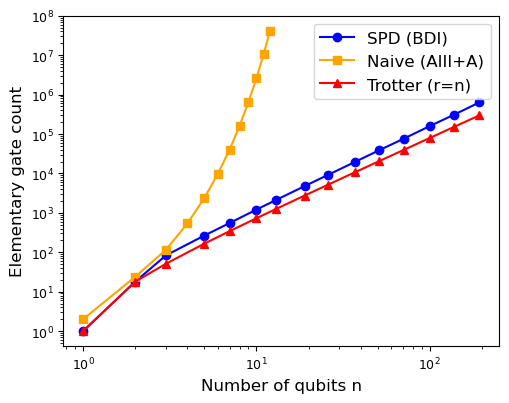

In [33]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["elementary_total"], "o-", color="blue", label="SPD (BDI)")
ax.plot(naive["n_qubits"], naive["elementary_total"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(trot_rep["n_qubits"], trot_rep["elementary_total"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Elementary gate count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "gate_count_comparison.png"), dpi=150)
plt.show()


## CNOT count vs n
The hardware-relevant two-qubit gate count.

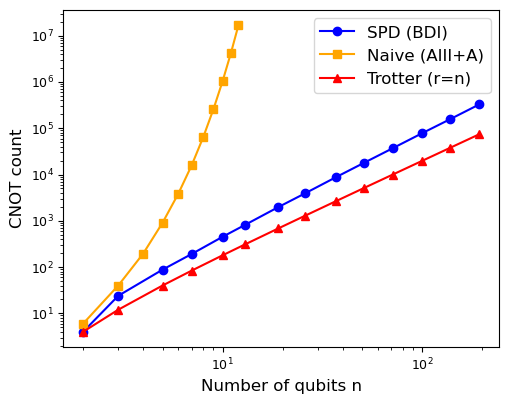

In [34]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

thry = np.linspace(1, 200, 100)

# n=1 has no coupling term -> cnot = 0 (undefined on a log axis); drop it.
_t, _n, _r = pos(tfim, "cnot"), pos(naive, "cnot"), pos(trot_rep, "cnot")
ax.plot(_t["n_qubits"], _t["cnot"], "o-", color="blue", label="SPD (BDI)")
ax.plot(_n["n_qubits"], _n["cnot"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(_r["n_qubits"], _r["cnot"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("CNOT count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "CNOT_count.png"), dpi=150)
plt.show()


## Pauli Gate Count vs n
Also plot the total gate counts before turning it into elementary gates for comparison.

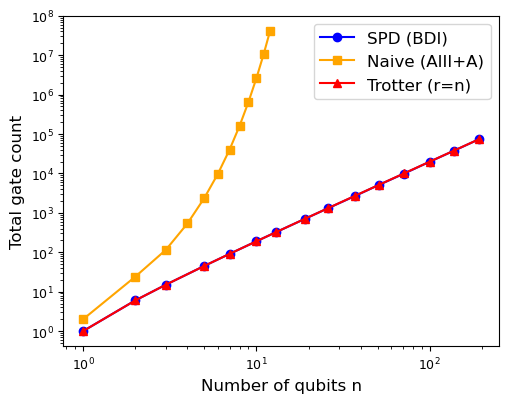

In [35]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

thry = np.linspace(2, 200, 100)

ax.plot(tfim["n_qubits"], tfim["total_gates"], "o-", color="blue", label="SPD (BDI)")
ax.plot(naive["n_qubits"], naive["total_gates"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(trot_rep["n_qubits"], trot_rep["total_gates"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Total gate count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "total_gate_count.png"), dpi=150)
plt.show()


## Decomposition time vs n
TFIM vs Naive. (Trotter's decomposition is analytic — microseconds — so it is omitted here
and characterised separately below.) Only `decomposition_time` is comparable across methods;
`total_time` includes each method's very different setup cost.

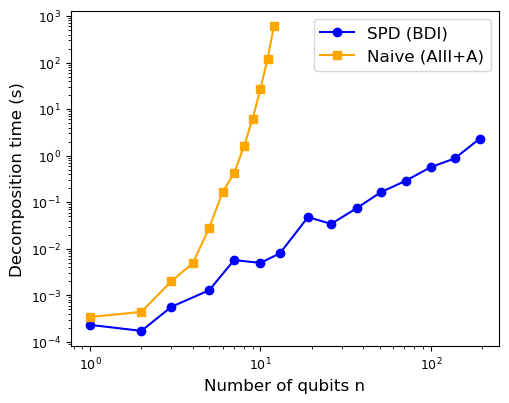

In [36]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["decomposition_time"], "o-", color="blue", label="SPD (BDI)")
ax.plot(naive["n_qubits"], naive["decomposition_time"], "s-", color="orange", label="Naive (AIII+A)")
#ax.plot(trot_rep["n_qubits"], trot_rep["decomposition_time"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Decomposition time (s)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "decomposition_time_comparison.png"), dpi=150)
plt.show()


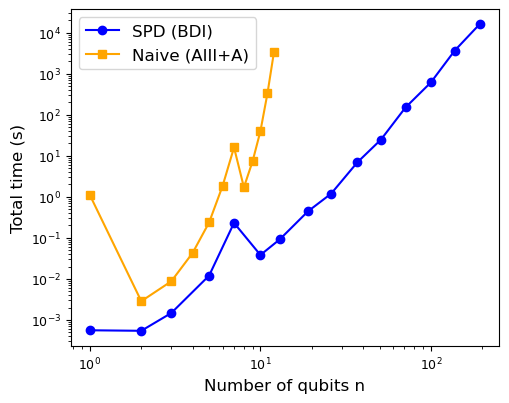

In [37]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["total_time"], "o-", color="blue", label="SPD (BDI)")
ax.plot(naive["n_qubits"], naive["total_time"], "s-", color="orange", label="Naive (AIII+A)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Total time (s)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "total_time_comparison.png"), dpi=150)
plt.show()

## Reconstruction error vs n
Available only for small n. **Note:** TFIM and Naive errors are *numerical* (both are exact
decompositions, so ~1e-14), whereas Trotter error is *algorithmic* (first-order Trotter is an
approximation) — they are qualitatively different and shown together only for context.

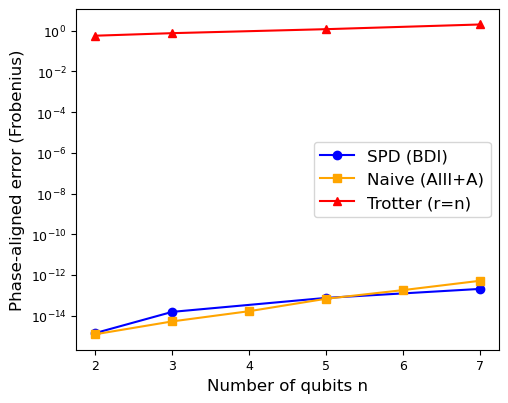

In [38]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

for df, lab, c, m in [(tfim, "SPD (BDI)", "blue", "o"),
                      (naive, "Naive (AIII+A)", "orange", "s"),
                      (trot_rep, "Trotter (r=n)", "red", "^")]:
    d = clean_err(df)   # drop n=1 (degenerate) and sub-1e-14 float noise
    if d is not None and len(d):
        ax.plot(d["n_qubits"], d["error"], m + "-", color=c, label=lab)
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Phase-aligned error (Frobenius)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "reconstruction_error.png"), dpi=150)
plt.show()


## Trotter characterisation: error and gate count vs Trotter steps r

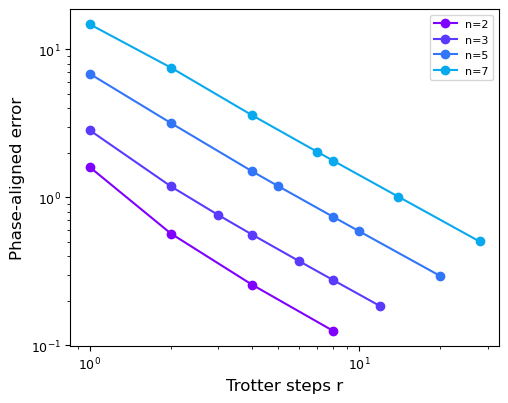

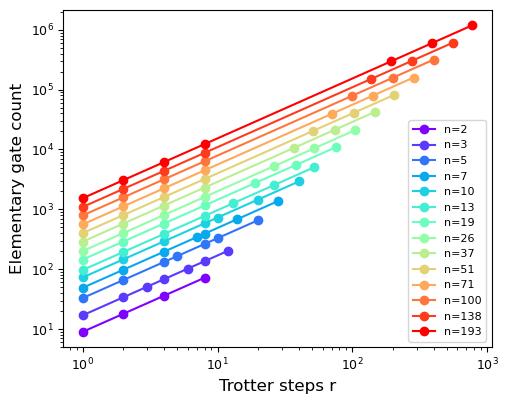

In [39]:
ns = sorted(n for n in trot["n_qubits"].unique() if n >= N_MIN)
cmap = plt.cm.rainbow
colors = {n: cmap(i / (len(ns) - 1)) for i, n in enumerate(ns)}

for (col, ylabel, save_file) in ([
        ("error", "Phase-aligned error", "trotter_error.png"),
        ("elementary_total", "Elementary gate count", "trotter_gate_count.png"),
    ]):
        plt.rcParams.update({
            "font.size": 12,
            "axes.labelsize": 12,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 12,
        })

        # Plot only the risk-return tradeoff
        scaling_factor = 1.5
        fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))
        for n, g in trot.groupby("n_qubits"):
            if n < N_MIN:
                continue
            g = g.sort_values("trotter_steps")
            if col == "error":
                g = g.dropna(subset=["error"])
                g = g[g["error"] > ERR_FLOOR]
            if len(g):
                ax.plot(g["trotter_steps"], g[col], "o-", label=f"n={n}", color=colors[n])

        ax.set_xlabel("Trotter steps r")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, save_file), dpi=150)
        plt.show()


## Scaling fits

Every scaling quoted in the discussion is fitted here directly from the loaded data, so the exponents/bases are reproducible rather than asserted. Power laws $y\sim n^{b}$ are fit on log--log axes (slope $=b$); exponentials $y\sim \text{base}^{n}$ on semilog. For the Naive *timings* the $n=1$ point is excluded, as it carries one-time start-up overhead (library/device initialisation) and is not representative of the scaling.

In [40]:
import numpy as np

def fit_power(x, y):
    """Fit y ~ n^b on log--log; return exponent b (or None)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return None if m.sum() < 2 else float(np.polyfit(np.log(x[m]), np.log(y[m]), 1)[0])

def fit_exp(x, y):
    """Fit y ~ base^n on semilog; return base (or None)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = (y > 0) & np.isfinite(x) & np.isfinite(y)
    return None if m.sum() < 2 else float(np.exp(np.polyfit(x[m], np.log(y[m]), 1)[0]))

def P(label, v, kind="n"):
    if v is None:
        print(f"  {label:32s}: insufficient data")
    else:
        print(f"  {label:32s} ~ " + (f"n^{v:.2f}" if kind == "n" else f"{v:.2f}^n"))

print("="*64)
print("POWER-LAW FITS   y ~ n^b   (the polynomial methods)")
print("="*64)
if tfim is not None:
    P("TFIM  elementary gates",      fit_power(tfim.n_qubits, tfim.elementary_total))
    P("TFIM  CNOT count",            fit_power(tfim.n_qubits, tfim.cnot))
    P("TFIM  decomposition time",    fit_power(tfim.n_qubits, tfim.decomposition_time))
    P("TFIM  total pipeline time",   fit_power(tfim.n_qubits, tfim.total_time))
if trot_rep is not None:
    P("Trotter(r=n) elementary",     fit_power(trot_rep.n_qubits, trot_rep.elementary_total))
    P("Trotter(r=n) CNOT",           fit_power(trot_rep.n_qubits, trot_rep.cnot))

print()
print("="*64)
print("EXPONENTIAL FITS   y ~ base^n   (Naive)")
print("="*64)
if naive is not None:
    P("Naive elementary gates",      fit_exp(naive.n_qubits, naive.elementary_total), "e")
    P("Naive CNOT count",            fit_exp(naive.n_qubits, naive.cnot), "e")
    nz = naive[naive.n_qubits >= 2]   # drop n=1 one-time start-up outlier for timings
    P("Naive decomp time (n>=2)",     fit_exp(nz.n_qubits, nz.decomposition_time), "e")
    P("Naive total time  (n>=2)",     fit_exp(nz.n_qubits, nz.total_time), "e")
    big = naive[naive.n_qubits >= 8]
    if len(big) >= 2:
        P("Naive total time  (n>=8)", fit_exp(big.n_qubits, big.total_time), "e")
        rr = big.total_time.values
        ratios = [f"{rr[i]/rr[i-1]:.1f}x" for i in range(1, len(rr))]
        print(f"    per-step ratios (n>=8): {ratios}  -> trending toward 8^n")
        print("    (full-Hilbert matrix exponential costs O((2^n)^3) = O(8^n))")

print()
print("="*64)
print("TROTTER vs r   (per qubit count, where error is available)")
print("="*64)
if trot is not None:
    for n, g in trot.groupby("n_qubits"):
        if n < N_MIN:
            continue
        ge = g.dropna(subset=["error"]).sort_values("trotter_steps")
        ge = ge[ge.error > ERR_FLOOR]
        if len(ge) < 2:
            continue
        se  = fit_power(ge.trotter_steps, ge.error)
        C   = float(np.median(ge.error.values * ge.trotter_steps.values))
        sg  = fit_power(g.trotter_steps, g.elementary_total)
        gps = float(np.median(g.elementary_total.values / g.trotter_steps.values))
        print(f"  n={int(n):>2}: error ~ r^{se:+.2f}, C=err*r~{C:5.2f}   |   "
              f"gates ~ r^{sg:+.2f}, gates/step={gps:.0f}")

print()
print("="*64)
print("TFIM / Trotter(r=n) RATIO   (widens with n)")
print("="*64)
if tfim is not None and trot_rep is not None:
    mg = tfim.merge(trot_rep, on="n_qubits", suffixes=("_t", "_r"))
    for n in [7, 19, 51, 100, 193]:
        row = mg[mg.n_qubits == n]
        if len(row):
            row = row.iloc[0]
            print(f"  n={n:>3}: elementary {row.elementary_total_t/row.elementary_total_r:.2f}x   "
                  f"CNOT {row.cnot_t/row.cnot_r:.2f}x")


POWER-LAW FITS   y ~ n^b   (the polynomial methods)
  TFIM  elementary gates           ~ n^2.35
  TFIM  CNOT count                 ~ n^2.36
  TFIM  decomposition time         ~ n^1.88
  TFIM  total pipeline time        ~ n^3.41
  Trotter(r=n) elementary          ~ n^2.23
  Trotter(r=n) CNOT                ~ n^2.11

EXPONENTIAL FITS   y ~ base^n   (Naive)
  Naive elementary gates           ~ 4.38^n
  Naive CNOT count                 ~ 4.30^n
  Naive decomp time (n>=2)         ~ 4.04^n
  Naive total time  (n>=2)         ~ 3.55^n
  Naive total time  (n>=8)         ~ 6.65^n
    per-step ratios (n>=8): ['4.3x', '5.4x', '8.4x', '10.0x']  -> trending toward 8^n
    (full-Hilbert matrix exponential costs O((2^n)^3) = O(8^n))

TROTTER vs r   (per qubit count, where error is available)
  n= 2: error ~ r^-1.22, C=err*r~ 1.08   |   gates ~ r^+1.00, gates/step=9
  n= 3: error ~ r^-1.09, C=err*r~ 2.24   |   gates ~ r^+1.00, gates/step=17
  n= 5: error ~ r^-1.05, C=err*r~ 5.96   |   gates ~ r^+1.00, 